# Exploratory Data Analysis of Student Academic Performance

##### - Data Cleaning
##### - Exploratory Data Analysis
##### - Feature Engineering
##### - Insights

## 📦 Step 1: Import Libraries
Import numpy, pandas, matplotlib.pyplot, seaborn.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Step 2: Load Dataset
Load `../data/studentperformance.csv`.

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [9]:
# ---------------- SHAPE --------------
df.shape

(1000, 8)

In [11]:
# --------------- INFO() ----------------
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [15]:
# ---------------- COLUMNS ----------------
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [5]:
# ---------------------- TOP 5 ROWS ----------------------------
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
# -------------------- LAST 5 ROWS ----------------------------
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [7]:
# ------------------ STATISTICAL SUMMARY----------------------
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
# -------------------- STATISTICAL SUMMARY IN CATIGARICAL COLUMNS---------------
df.describe(include=object)

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


### Step 3: Missing Values Check

In [18]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### Step 4: Gender Distribution

In [19]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

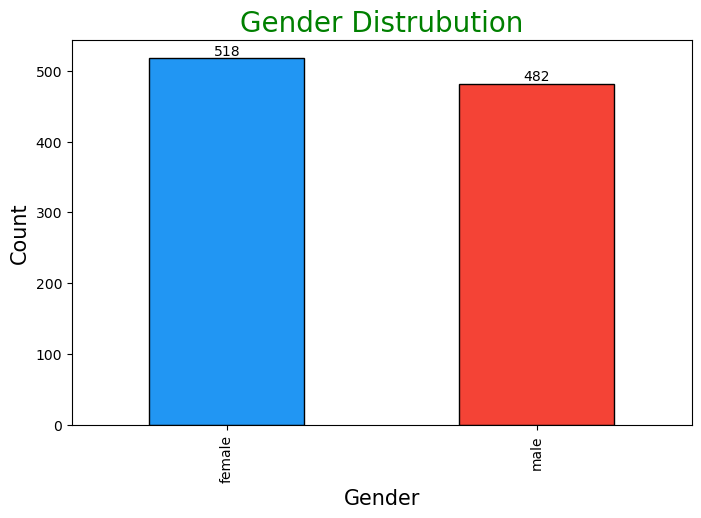

Female and male students are almost equally distributed.


In [5]:
plt.figure(figsize=(8,5))
color = ['#2196F3', '#F44336']
ax=df['gender'].value_counts().plot(kind='bar',color=color,edgecolor='black',width=0.5)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Gender Distrubution',color='g',size=20)
plt.xlabel('Gender',size=15)
plt.ylabel('Count',size=15)
plt.show()

print('='*40)
print('Female and male students are almost equally distributed.')
print('='*40)

### Step 5: Score Distributions

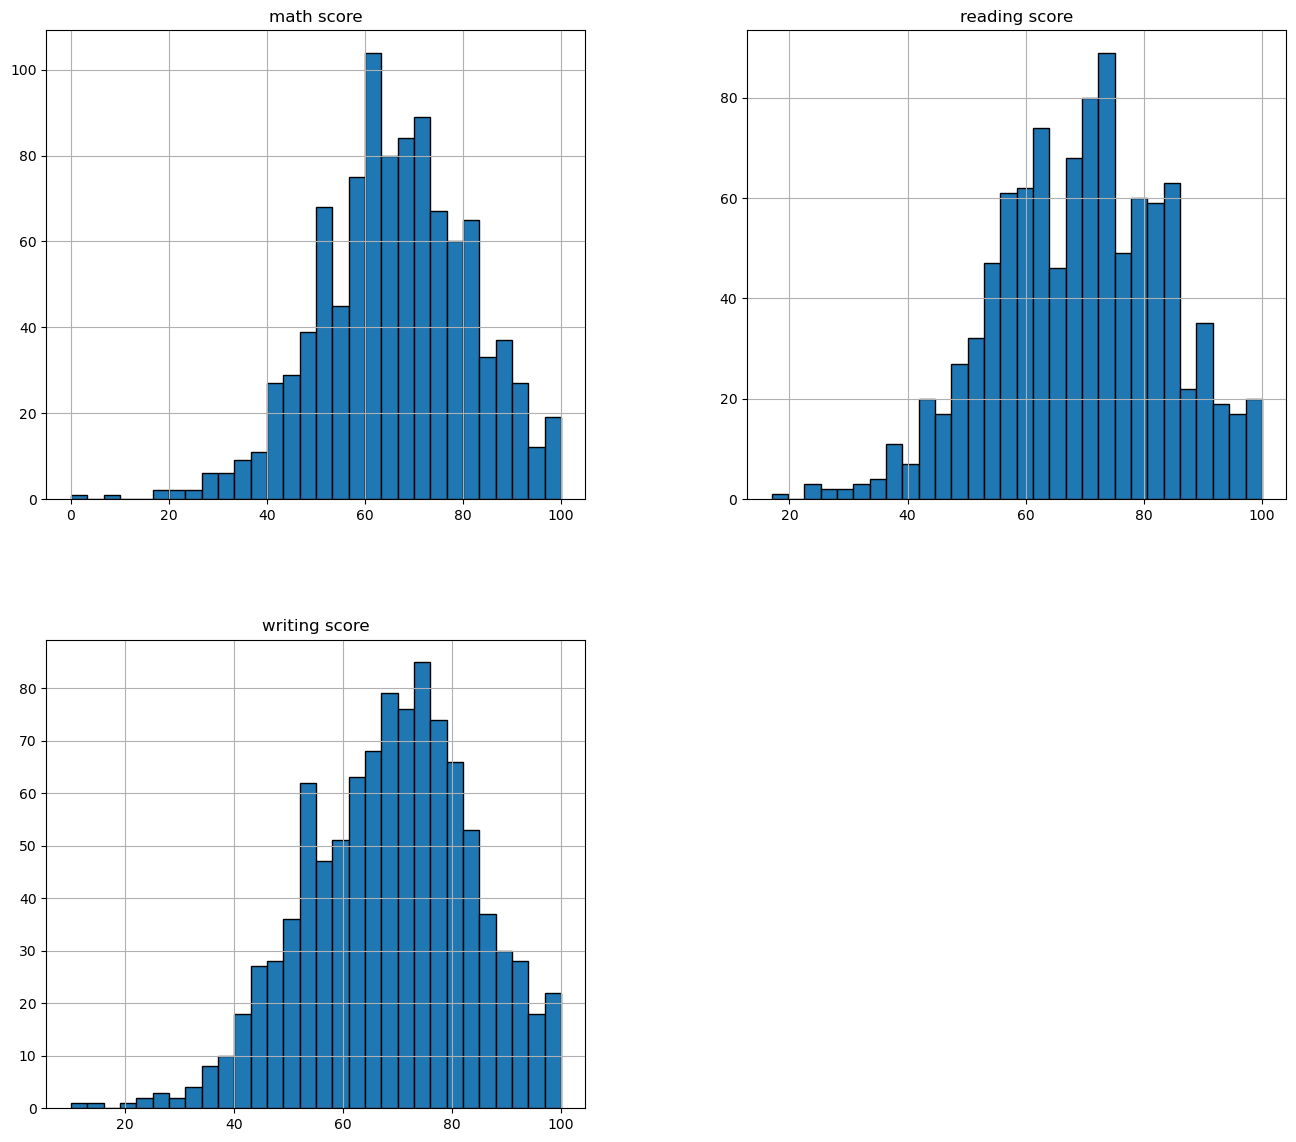

Most students scored between 50 and 80 marks.


In [41]:
df[['math score','reading score','writing score']].hist(
    figsize=(16,14),edgecolor='black',bins=30
)
plt.show()

print('='*40)
print('Most students scored between 50 and 80 marks.')
print('='*40)

In [66]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

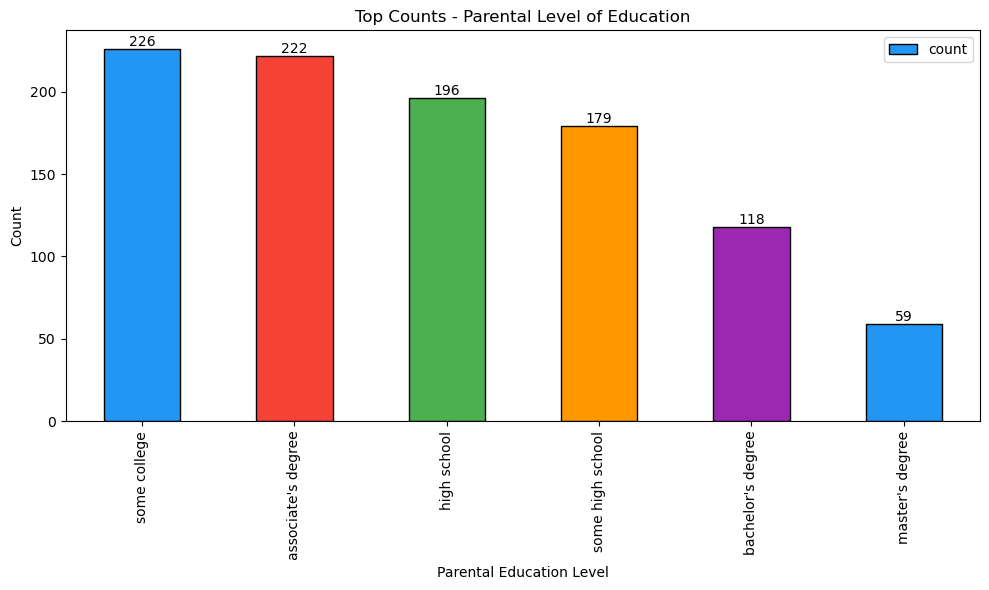

In [6]:
plt.figure(figsize=(10,6))
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0','#2196F3']
ax=df['parental level of education'].value_counts().plot(kind='bar',color=colors,edgecolor='black')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Top Counts - Parental Level of Education")
plt.xlabel("Parental Education Level")
plt.ylabel("Count")
plt.tight_layout()
plt.legend()

###### Most parents have **some college or associate's degree** education level.
###### **Master's degree** parents are the least represented.

### Lunch Type Distrubution

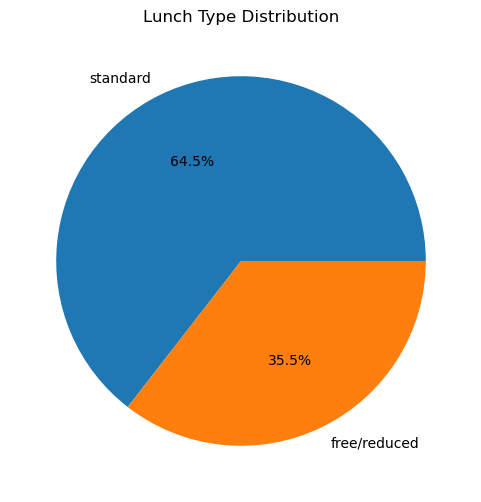

In [45]:
lunch_counts = df['lunch'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(lunch_counts,labels=lunch_counts.index,autopct='%1.1f%%')

plt.title("Lunch Type Distribution")

plt.show()

### Step 6: Average Scores

In [91]:
df[['math score','reading score','writing score']].mean()

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

### Boxplot
 - Gender wise math score

In [94]:
df.groupby('gender')['math score'].mean()

gender
female    63.633205
male      68.728216
Name: math score, dtype: float64

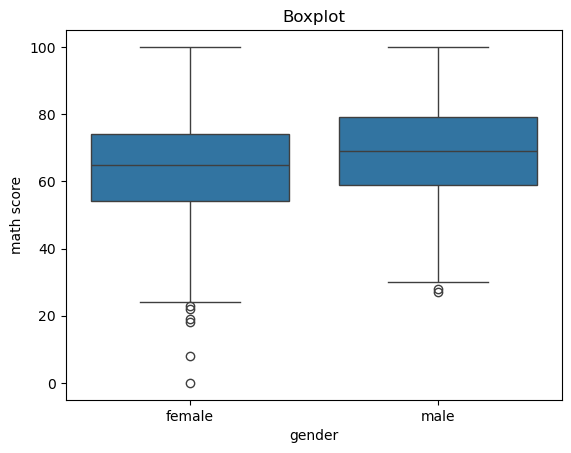

In [99]:
sns.boxplot(x='gender',y='math score',data=df)
plt.title('Boxplot')
plt.show()

### Step 7: Correlation Analysis

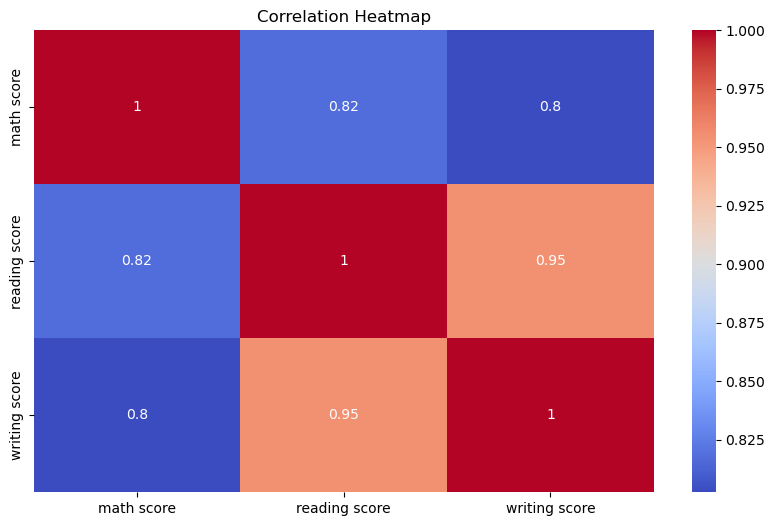

In [110]:
cols = [ 'math score','reading score','writing score']

plt.figure(figsize=(10,6))

sns.heatmap(
    df[cols].corr(),
    annot=True,                               #annot=True  means values in box 
    cmap='coolwarm')        

plt.title('Correlation Heatmap')
plt.show()

### Add column in Total

In [8]:
df['Total']=df['math score']+df['reading score']+df['writing score']

In [9]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282
996,male,group C,high school,free/reduced,none,62,55,55,172
997,female,group C,high school,free/reduced,completed,59,71,65,195
998,female,group D,some college,standard,completed,68,78,77,223


### Group wise Total average marks

In [11]:
df.groupby('race/ethnicity')['Total'].mean()

race/ethnicity
group A    188.977528
group B    196.405263
group C    201.394984
group D    207.538168
group E    218.257143
Name: Total, dtype: float64

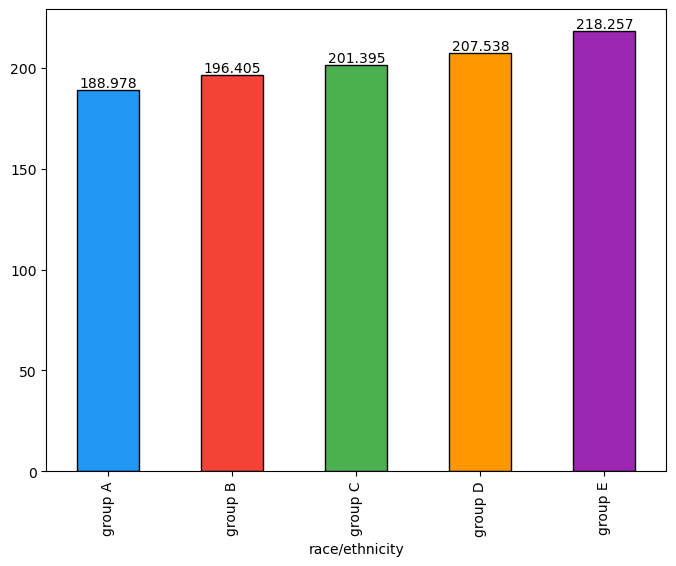

In [18]:
plt.figure(figsize=(8,6))
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0','#2196F3']

ax=df.groupby('race/ethnicity')['Total'].mean().plot(kind='bar',color=PALETTE,edgecolor='black')
for container in ax.containers:
    ax.bar_label(container)

In [21]:
df.groupby('gender')['Total'].mean()

gender
female    208.708494
male      197.512448
Name: Total, dtype: float64

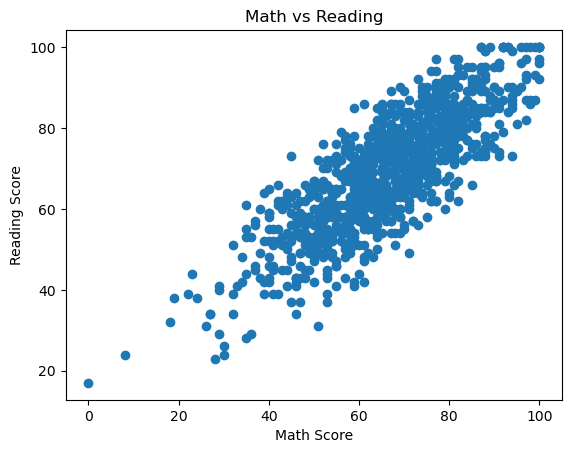

In [5]:
plt.scatter(df['math score'],df['reading score'])

plt.xlabel("Math Score")

plt.ylabel("Reading Score")

plt.title("Math vs Reading")

plt.show()

In [11]:
df.groupby(
'parental level of education'
)[['math score',
   'reading score',
   'writing score']].mean()

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


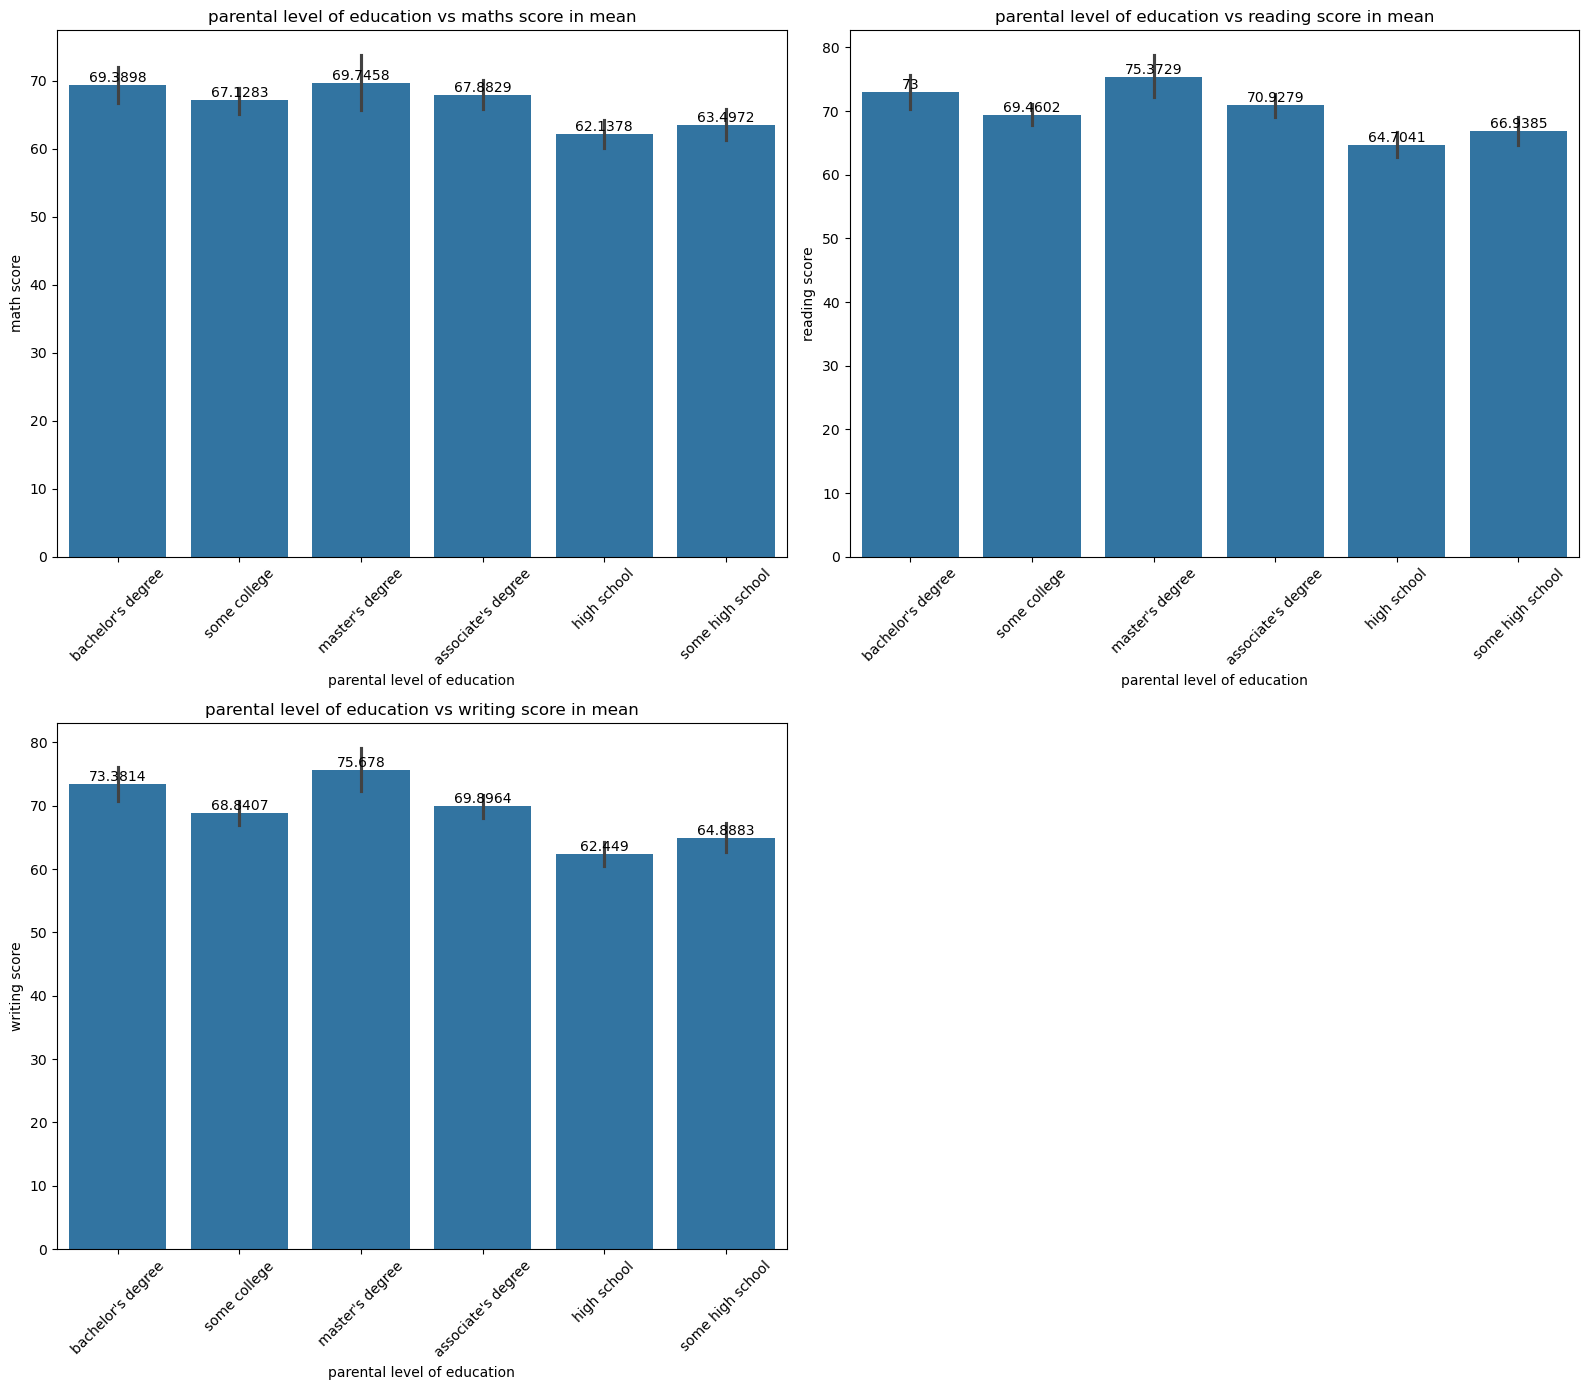

In [28]:
plt.figure(figsize=(16,14))
#PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']#,'#2196F3']

plt.subplot(2,2,1)
ax=sns.barplot(
    x='parental level of education',
    y='math score',
    data=df
)
for container in ax.containers:
    ax.bar_label(container)
plt.title('parental level of education vs maths score in mean')
plt.xticks(rotation=45)


plt.subplot(2,2,2)
ax=sns.barplot(
    x='parental level of education',
    y='reading score',
    data=df
)
for container in ax.containers:
    ax.bar_label(container)
plt.title('parental level of education vs reading score in mean')
plt.xticks(rotation=45)


plt.subplot(2,2,3)
ax=sns.barplot(
    x='parental level of education',
    y='writing score',
    data=df
)
for container in ax.containers:
    ax.bar_label(container)
plt.title('parental level of education vs writing score in mean')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
df.groupby('gender')[
['math score',
 'reading score',
 'writing score']
].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [31]:
df[['math score',
    'reading score',
    'writing score']].mean()

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

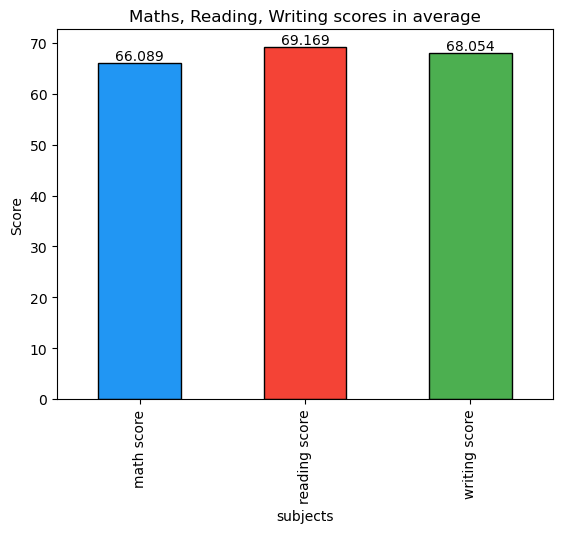

In [38]:
ax=df[['math score','reading score','writing score']].mean().plot(kind='bar',color=PALETTE,edgecolor='black')
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0','#2196F3']
for container in ax.containers:
    ax.bar_label(container)
plt.title('Maths, Reading, Writing scores in average')
plt.xlabel('subjects')
plt.ylabel('Score')
plt.show()

###  Key Insights

- Female students scored higher in reading and writing.
- Test preparation course positively impacted performance.
- Students with standard lunch performed better.
- Reading and writing scores showed strong correlation.
- Higher parental education was associated with better student performance.